In [28]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [29]:
# Path to your metrics file(s).
# Common patterns:
#   metrics.jsonl
#   logs/metrics.jsonl
#   logs/*.jsonl
LOG_GLOB = "metrics.jsonl"   # <-- change this to your path/glob

# Keys in your JSON lines
STEP_KEY = "global_step"
LOSS_KEY = "loss/out"

# Optional: smooth the loss curve (moving average window size in points)
SMOOTH_WINDOW = 50   # set to 0 to disable smoothing

# Optional: keep only every N points to speed up plotting for very large logs
DOWNSAMPLE_EVERY = 1  # e.g., 10 means keep every 10th record


In [30]:
def read_jsonl_files(glob_pattern: str) -> pd.DataFrame:
    paths = sorted(Path(".").glob(glob_pattern))
    if not paths:
        raise FileNotFoundError(
            f"No files matched {glob_pattern!r}. "
            "Update LOG_GLOB to point to your metrics JSONL."
        )

    rows = []
    bad_lines = 0

    for p in paths:
        with p.open("r", encoding="utf-8") as f:
            for line_no, line in enumerate(f, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    bad_lines += 1

    df = pd.DataFrame(rows)
    print(f"Loaded {len(df):,} records from {len(paths)} file(s).")
    if bad_lines:
        print(f"Warning: skipped {bad_lines:,} malformed line(s).")
    return df

df_raw = read_jsonl_files(LOG_GLOB)

# Show a quick peek
df_raw.head()


Loaded 2,241 records from 1 file(s).


,global_step,acc_step,speed/wps,speed/FLOPS,speed/curr_iter_time,speed/data_load_time,optim/grad_norm,optim/lr,optim/total_tokens,memory/max_active_gib,memory/max_active_pct,memory/max_reserved_gib,memory/max_reserved_pct,memory/num_alloc_retries,memory/num_ooms,memory/power_draw,loss/out,created_at
0,1,0,13.931000,6.847538e+10,1.5757,0.2343,18.110075,0.000000e+00,432,9.865370,22.217884,11.937500,26.884546,0,0,110672,12.321185,2026-01-08T19:44:51.736907+00:00
1,2,0,230.079115,1.124840e+12,0.8303,0.0005,15.790436,5.000000e-07,736,12.762187,28.741832,16.105469,36.271265,0,0,120107,12.300704,2026-01-08T19:44:53.581044+00:00
2,3,0,279.268403,1.381860e+12,0.7714,0.0004,18.540907,1.000000e-06,1440,12.992936,29.261502,16.794922,37.823988,0,0,123321,11.990537,2026-01-08T19:44:55.042605+00:00
3,4,0,303.646124,1.505970e+12,0.7754,0.0003,17.451757,1.500000e-06,1536,12.917092,29.090694,16.794922,37.823988,0,0,124976,12.212247,2026-01-08T19:44:56.492239+00:00
4,5,0,391.179306,1.950091e+12,0.7748,0.0004,15.330267,2.000000e-06,3440,13.333760,30.029075,16.794922,37.823988,0,0,129110,12.224380,2026-01-08T19:44:57.944840+00:00


In [31]:
def extract_step_loss(df: pd.DataFrame, step_key: str, loss_key: str) -> pd.DataFrame:
    if step_key not in df.columns:
        raise KeyError(f"Missing {step_key!r} in columns: {list(df.columns)}")
    if loss_key not in df.columns:
        raise KeyError(f"Missing {loss_key!r} in columns: {list(df.columns)}")

    out = df[[step_key, loss_key]].copy()
    out = out.rename(columns={step_key: "step", loss_key: "loss"})
    out["step"] = pd.to_numeric(out["step"], errors="coerce")
    out["loss"] = pd.to_numeric(out["loss"], errors="coerce")
    out = out.dropna(subset=["step", "loss"])
    out = out.sort_values("step").drop_duplicates(subset=["step"], keep="last").reset_index(drop=True)
    return out

df = extract_step_loss(df_raw, STEP_KEY, LOSS_KEY)

# Optional downsample
if DOWNSAMPLE_EVERY and DOWNSAMPLE_EVERY > 1:
    df = df.iloc[::DOWNSAMPLE_EVERY].reset_index(drop=True)

df.describe()


,step,loss
count,2241.000000,2241.000000
mean,1121.000000,7.218567
std,647.065298,0.964477
min,1.000000,3.527127
25%,561.000000,6.618623
50%,1121.000000,7.199958
75%,1681.000000,7.759892
max,2241.000000,12.321185


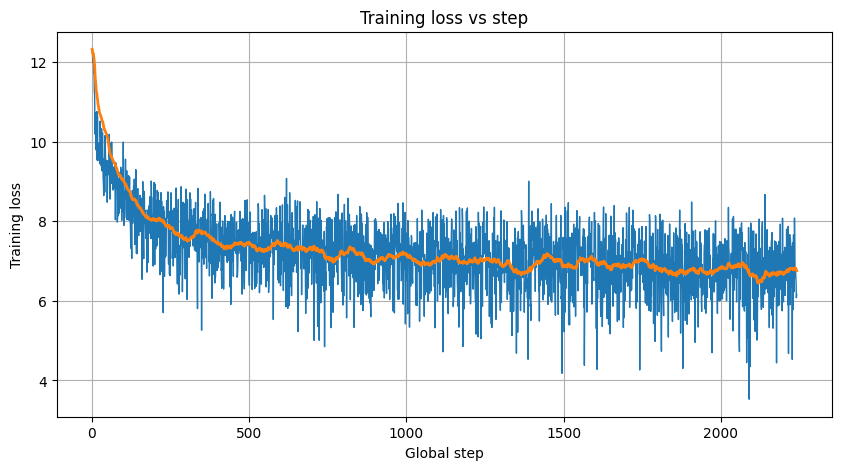

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(df["step"], df["loss"], linewidth=1)

if SMOOTH_WINDOW and SMOOTH_WINDOW > 1 and len(df) >= SMOOTH_WINDOW:
    smooth = df["loss"].rolling(SMOOTH_WINDOW, min_periods=1).mean()
    plt.plot(df["step"], smooth, linewidth=2)

plt.xlabel("Global step")
plt.ylabel("Training loss")
plt.title("Training loss vs step")
plt.grid(True)
plt.show()


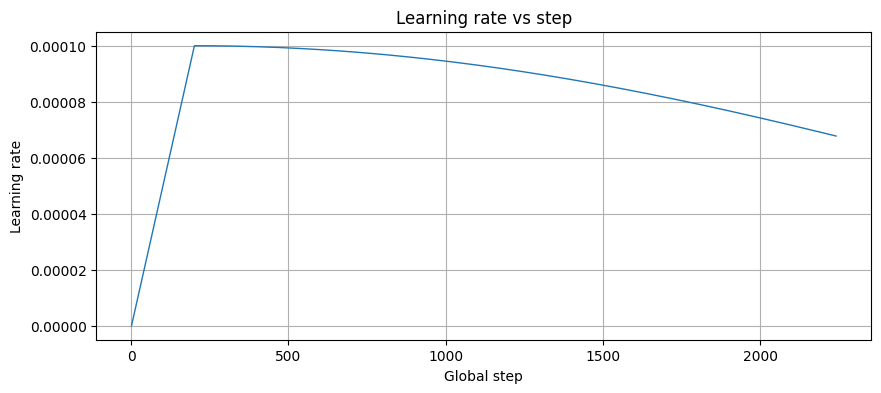

In [33]:
LR_KEY = "optim/lr"
if LR_KEY in df_raw.columns:
    tmp = df_raw[[STEP_KEY, LR_KEY]].copy()
    tmp = tmp.rename(columns={STEP_KEY: "step", LR_KEY: "lr"})
    tmp["step"] = pd.to_numeric(tmp["step"], errors="coerce")
    tmp["lr"] = pd.to_numeric(tmp["lr"], errors="coerce")
    tmp = tmp.dropna().sort_values("step").drop_duplicates("step", keep="last")
    if DOWNSAMPLE_EVERY and DOWNSAMPLE_EVERY > 1:
        tmp = tmp.iloc[::DOWNSAMPLE_EVERY]

    plt.figure(figsize=(10, 4))
    plt.plot(tmp["step"], tmp["lr"], linewidth=1)
    plt.xlabel("Global step")
    plt.ylabel("Learning rate")
    plt.title("Learning rate vs step")
    plt.grid(True)
    plt.show()
else:
    print(f"{LR_KEY!r} not found in logs.")


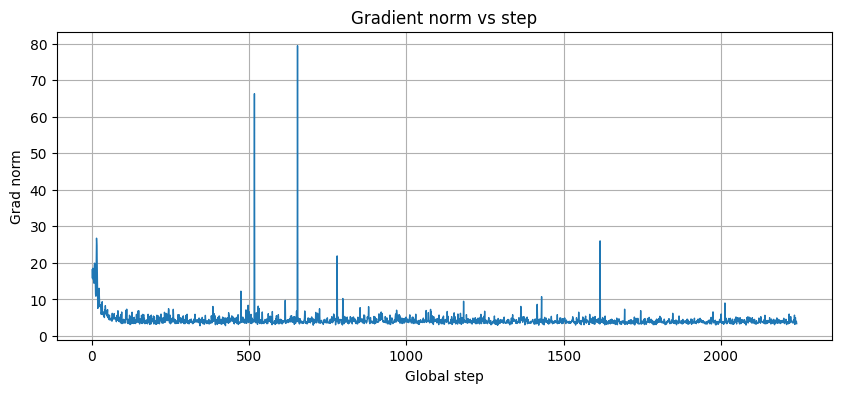

In [34]:
plt.figure(figsize=(10, 4))
plt.plot(df_raw["global_step"], df_raw["optim/grad_norm"], linewidth=1)
plt.xlabel("Global step")
plt.ylabel("Grad norm")
plt.title("Gradient norm vs step")
plt.grid(True)
plt.show()


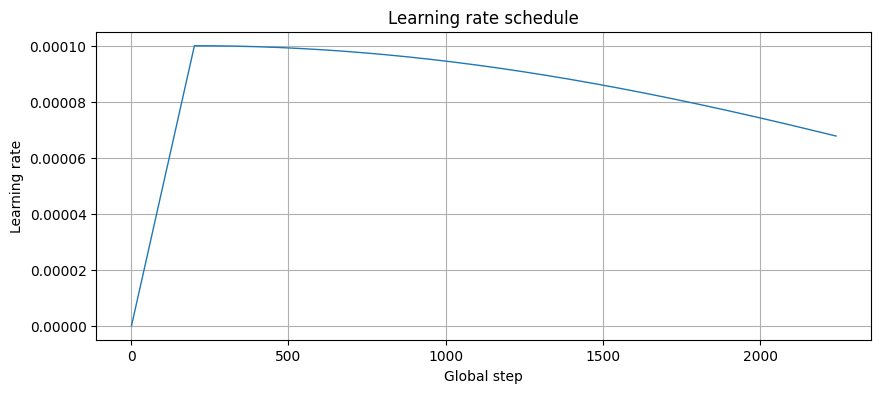

In [35]:
plt.figure(figsize=(10, 4))
plt.plot(df_raw["global_step"], df_raw["optim/lr"], linewidth=1)
plt.xlabel("Global step")
plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True)
plt.show()


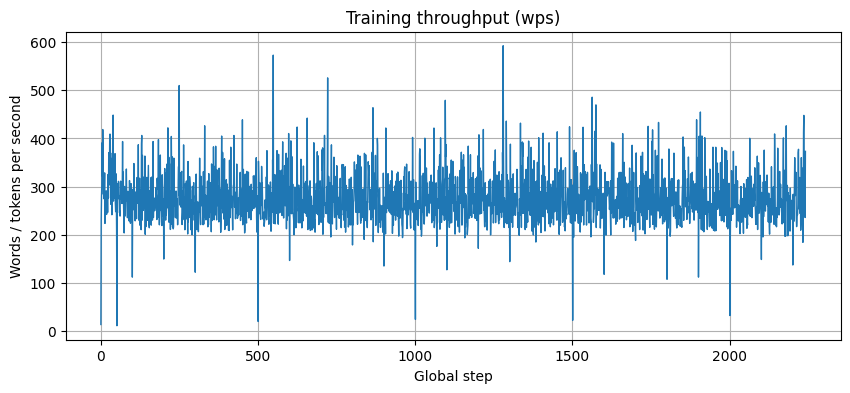

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(df_raw["global_step"], df_raw["speed/wps"], linewidth=1)
plt.xlabel("Global step")
plt.ylabel("Words / tokens per second")
plt.title("Training throughput (wps)")
plt.grid(True)
plt.show()


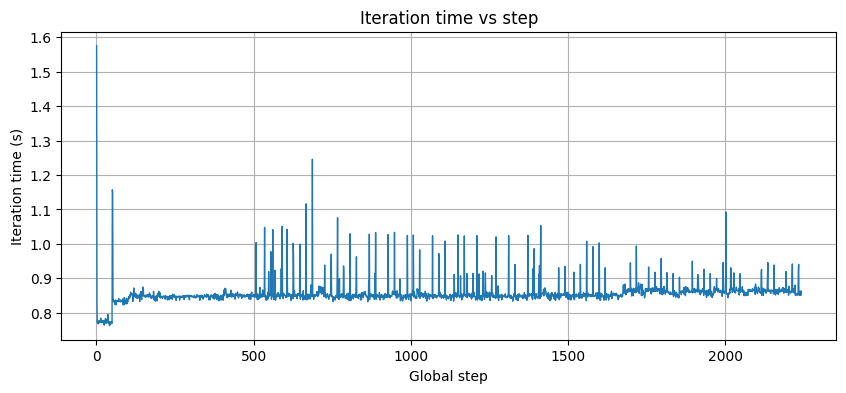

In [37]:
plt.figure(figsize=(10, 4))
plt.plot(df_raw["global_step"], df_raw["speed/curr_iter_time"], linewidth=1)
plt.xlabel("Global step")
plt.ylabel("Iteration time (s)")
plt.title("Iteration time vs step")
plt.grid(True)
plt.show()


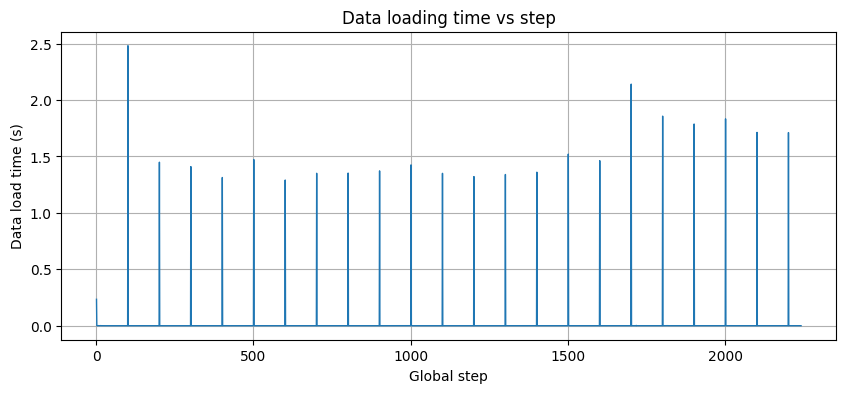

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(df_raw["global_step"], df_raw["speed/data_load_time"], linewidth=1)
plt.xlabel("Global step")
plt.ylabel("Data load time (s)")
plt.title("Data loading time vs step")
plt.grid(True)
plt.show()


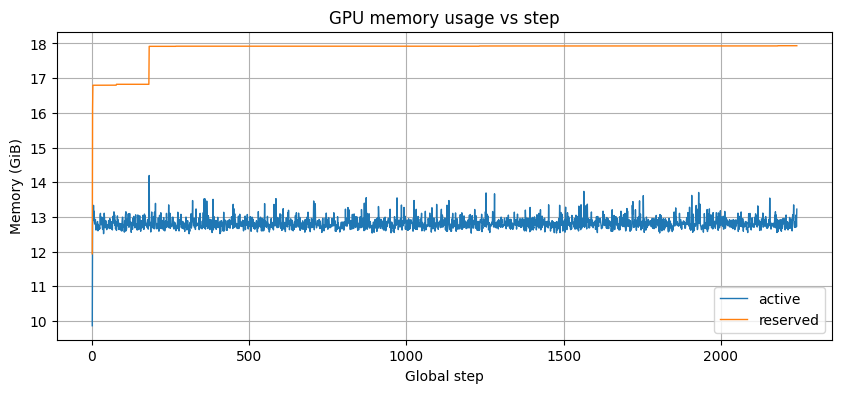

In [39]:
plt.figure(figsize=(10, 4))
plt.plot(df_raw["global_step"], df_raw["memory/max_active_gib"], label="active", linewidth=1)
plt.plot(df_raw["global_step"], df_raw["memory/max_reserved_gib"], label="reserved", linewidth=1)
plt.xlabel("Global step")
plt.ylabel("Memory (GiB)")
plt.title("GPU memory usage vs step")
plt.legend()
plt.grid(True)
plt.show()


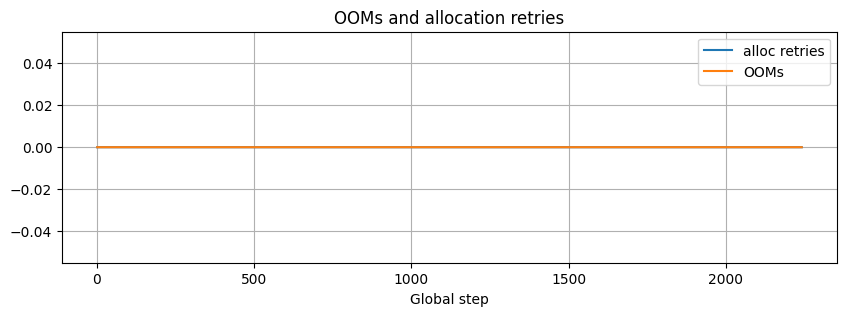

In [40]:
plt.figure(figsize=(10, 3))
plt.plot(df_raw["global_step"], df_raw["memory/num_alloc_retries"], label="alloc retries")
plt.plot(df_raw["global_step"], df_raw["memory/num_ooms"], label="OOMs")
plt.xlabel("Global step")
plt.title("OOMs and allocation retries")
plt.legend()
plt.grid(True)
plt.show()


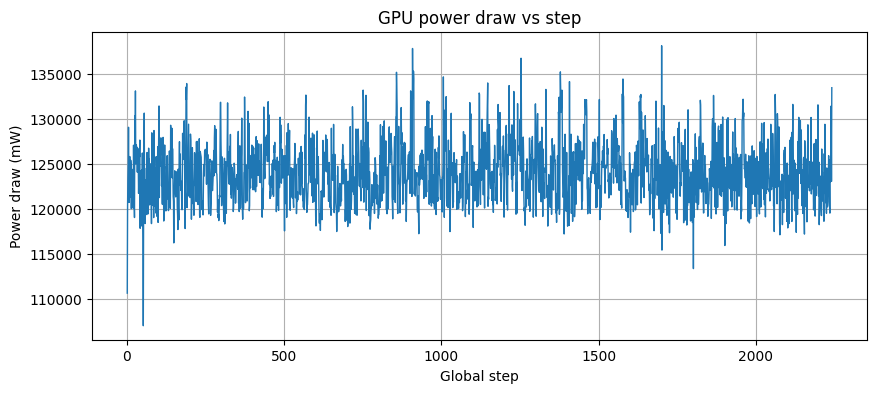

In [41]:
plt.figure(figsize=(10, 4))
plt.plot(df_raw["global_step"], df_raw["memory/power_draw"], linewidth=1)
plt.xlabel("Global step")
plt.ylabel("Power draw (mW)")
plt.title("GPU power draw vs step")
plt.grid(True)
plt.show()


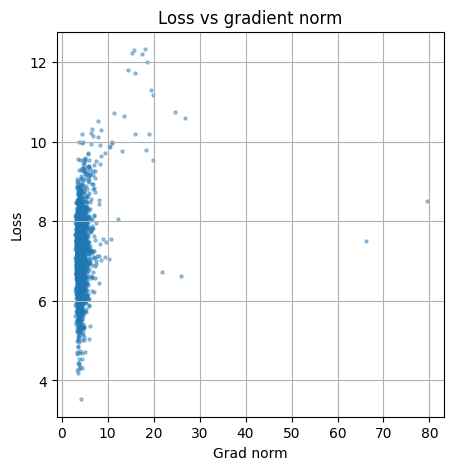

In [42]:
plt.figure(figsize=(5, 5))
plt.scatter(df_raw["optim/grad_norm"], df_raw["loss/out"], s=5, alpha=0.4)
plt.xlabel("Grad norm")
plt.ylabel("Loss")
plt.title("Loss vs gradient norm")
plt.grid(True)
plt.show()

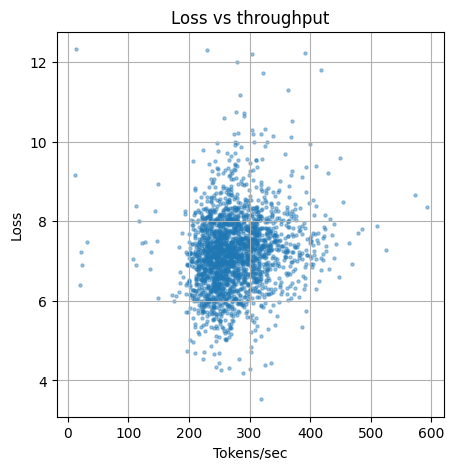

In [43]:
plt.figure(figsize=(5, 5))
plt.scatter(df_raw["speed/wps"], df_raw["loss/out"], s=5, alpha=0.4)
plt.xlabel("Tokens/sec")
plt.ylabel("Loss")
plt.title("Loss vs throughput")
plt.grid(True)
plt.show()
